Customer Segmentation Completed Successfully!

Sample Output:

First 10 Customer Segments:
   CustomerID  TotalAmount                Segment
0     12347.0        30.00  Medium Value Customer
1     12353.0        39.80  Medium Value Customer
2     12354.0        25.45     Low Value Customer
3     12360.0        33.90  Medium Value Customer
4     12372.0        10.08     Low Value Customer
5     12377.0        30.60  Medium Value Customer
6     12378.0        23.40     Low Value Customer
7     12391.0        35.40  Medium Value Customer
8     12393.0        27.00     Low Value Customer
9     12395.0        23.40     Low Value Customer


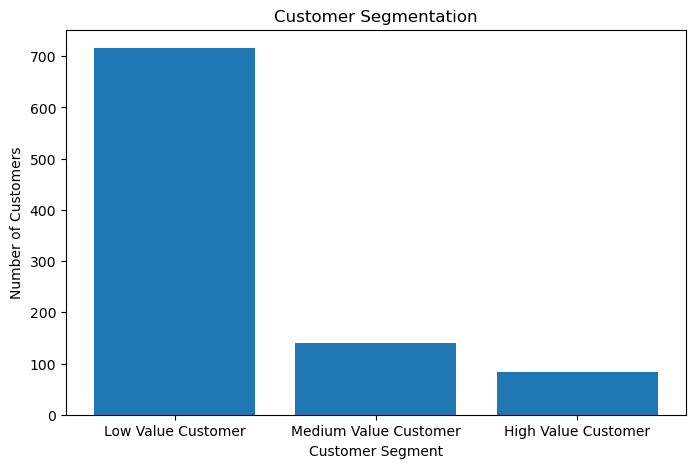

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("Online_Retail_Small.xlsx")
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
customer_df = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()
def segment_customer(amount):
    if amount >= 60:
        return "High Value Customer"
    elif amount >= 30:
        return "Medium Value Customer"
    else:
        return "Low Value Customer"
customer_df['Segment'] = customer_df['TotalAmount'].apply(segment_customer)
customer_df.to_csv("customer_segments.csv", index=False)
print("Customer Segmentation Completed Successfully!")
print("\nSample Output:")
print("\nFirst 10 Customer Segments:")
print(customer_df.head(10))
segment_counts = customer_df['Segment'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()